In [1]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt

In [2]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [3]:
day_ahead_price = pd.read_csv('Data/preprocessed/stacked_lmp_da_hr_data.csv')
day_ahead_price.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
real_time_price = pd.read_csv('Data/preprocessed/stacked_lmp_price_data.csv')
nat_gas_price = pd.read_csv('Data/preprocessed/nat_gas_price.csv')

price_data = pd.merge(day_ahead_price[['begin_time', 'NP-15 LMP', 'SP-15 LMP']], real_time_price[['begin_time', 'NP-15 LMP', 'SP-15 LMP']], how='inner', on='begin_time', suffixes=['_da', '_rt'])
price_data = pd.merge(price_data, nat_gas_price[['begin_time', 'Natural_gas_price']], how='inner', on='begin_time')
price_data['begin_time'] = pd.to_datetime(price_data['begin_time'])
price_data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price
0,2020-10-01 00:00:00,33.72815,33.27208,27.36302,27.31358,1.6
1,2020-10-01 01:00:00,32.86505,32.41749,30.65566,30.02947,1.6
2,2020-10-01 02:00:00,30.06186,29.42354,30.08861,28.64437,1.6
3,2020-10-01 03:00:00,30.06145,29.43873,29.38435,28.75657,1.6
4,2020-10-01 04:00:00,30.99357,30.28332,29.18814,28.58909,1.6
...,...,...,...,...,...,...
34497,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.4
34498,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.4
34499,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.4
34500,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.4


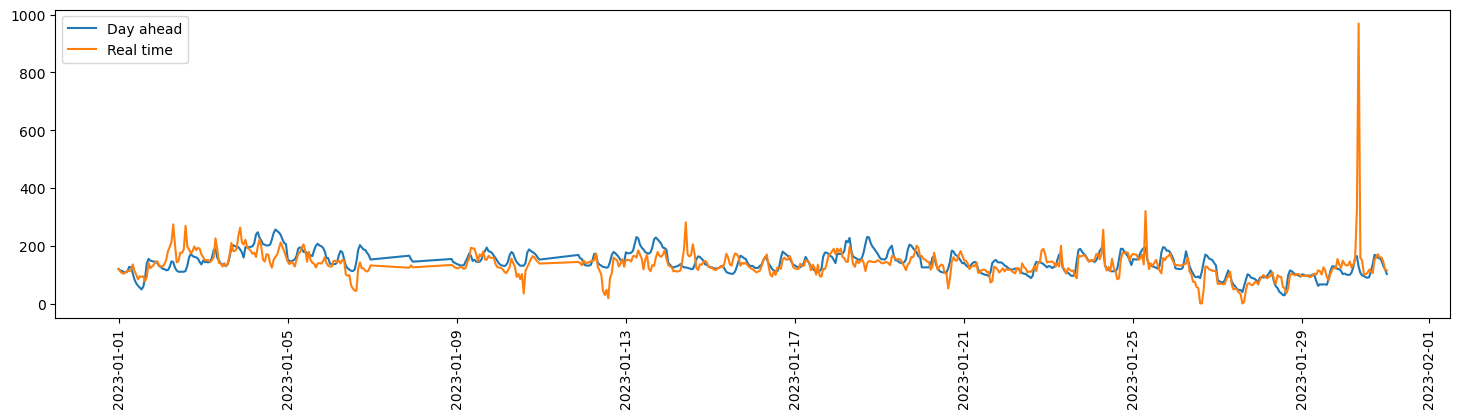

In [4]:
time1 = datetime.datetime(2023, 1, 1, 0, 0, 0)
time2 = datetime.datetime(2023, 1, 31, 0, 0, 0)

plt.figure(figsize=(18, 4))
plt.plot(price_data[filter_times(price_data, time1, time2)]['begin_time'], price_data[filter_times(price_data, time1, time2)]['NP-15 LMP_da'], label='Day ahead')
plt.plot(price_data[filter_times(price_data, time1, time2)]['begin_time'], price_data[filter_times(price_data, time1, time2)]['NP-15 LMP_rt'], label='Real time')

plt.xticks(rotation=90)
plt.legend()
plt.show()

In [5]:
klamath_river_data = pd.read_csv('Data/preprocessed/klamath_river_discharge.csv')
sacramento_river_data = pd.read_csv('Data/preprocessed/sacramento_river_discharge.csv')
river_discharge_data = pd.merge(klamath_river_data, sacramento_river_data, on='begin_time', how='inner', suffixes=['_klamath', '_sacramento'])
river_discharge_data['begin_time'] = pd.to_datetime(river_discharge_data['begin_time'])
price_river_data = pd.merge(price_data, river_discharge_data, on='begin_time', how='inner')

In [6]:
price_river_data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento
0,2020-10-01 00:00:00,33.72815,33.27208,27.36302,27.31358,1.6,2270,14200.0
1,2020-10-01 01:00:00,32.86505,32.41749,30.65566,30.02947,1.6,2250,14100.0
2,2020-10-01 02:00:00,30.06186,29.42354,30.08861,28.64437,1.6,2230,13200.0
3,2020-10-01 03:00:00,30.06145,29.43873,29.38435,28.75657,1.6,2230,10300.0
4,2020-10-01 04:00:00,30.99357,30.28332,29.18814,28.58909,1.6,2230,6980.0
...,...,...,...,...,...,...,...,...
34468,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.4,84500,54300.0
34469,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.4,83100,54900.0
34470,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.4,81900,54600.0
34471,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.4,81100,55000.0


In [7]:
pge_load = pd.read_csv('Data/load_1hr_PGE.csv')
pge_load.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
sce_load = pd.read_csv('Data/load_1hr_SCE.csv')
sce_load.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
load_data = pd.merge(pge_load[['begin_time', 'load']], sce_load[['begin_time', 'load']], on='begin_time', how='inner', suffixes=['_PGE', '_SCE'])
load_data['begin_time'] = pd.to_datetime(load_data['begin_time']).apply(lambda x : x.tz_localize(None))
load_data

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_12454/3938173778.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  load_data['begin_time'] = pd.to_datetime(load_data['begin_time']).apply(lambda x : x.tz_localize(None))


,begin_time,load_PGE,load_SCE
0,2020-01-01 00:00:00,10206,9184
1,2020-01-01 01:00:00,9866,8876
2,2020-01-01 02:00:00,9605,8667
3,2020-01-01 03:00:00,9453,8563
4,2020-01-01 04:00:00,9389,8562
...,...,...,...
41610,2024-12-31 19:00:00,11307,10952
41611,2024-12-31 20:00:00,10967,10667
41612,2024-12-31 21:00:00,10614,10503
41613,2024-12-31 22:00:00,10226,10237


In [8]:
load_forecast = pd.read_csv('Data/preprocessed/stacked_load_forecast_data.csv')
load_forecast.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)':'begin_time'}, inplace=True)
load_forecast['begin_time'] = pd.to_datetime(load_forecast['begin_time'])
load_all = pd.merge(load_data, load_forecast[['begin_time', 'Pacific Gas and Electric Forecast Load (MW)', 'Southern California Edison Forecast Load (MW)']], on='begin_time', how='inner')
load_all

,begin_time,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW)
0,2021-03-12 00:00:00,9914,9763,10102.72,9686.47
1,2021-03-12 01:00:00,9827,9536,9868.57,9474.64
2,2021-03-12 02:00:00,9849,9416,9712.50,9339.19
3,2021-03-12 03:00:00,9939,9475,9715.76,9304.25
4,2021-03-12 04:00:00,10287,9842,9969.51,9545.95
...,...,...,...,...,...
29620,2024-12-31 19:00:00,11307,10952,11959.79,10989.78
29621,2024-12-31 20:00:00,10967,10667,11723.02,10760.92
29622,2024-12-31 21:00:00,10614,10503,11408.80,10646.09
29623,2024-12-31 22:00:00,10226,10237,10831.46,10435.11


In [9]:
price_river_load_data = pd.merge(price_river_data, load_all, on='begin_time', how='inner')
price_river_load_data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW)
0,2021-03-12 00:00:00,42.96548,40.78043,34.56084,33.48478,2.65,11900,14800.0,9914,9763,10102.72,9686.47
1,2021-03-12 01:00:00,39.48897,37.76416,33.10504,32.01413,2.65,11900,14400.0,9827,9536,9868.57,9474.64
2,2021-03-12 02:00:00,39.09879,37.50715,34.53900,33.43611,2.65,11900,12500.0,9849,9416,9712.50,9339.19
3,2021-03-12 03:00:00,39.38309,37.79894,33.62841,32.36996,2.65,11900,8930.0,9939,9475,9715.76,9304.25
4,2021-03-12 04:00:00,41.92228,40.13255,34.56917,33.48674,2.65,11800,6770.0,10287,9842,9969.51,9545.95
...,...,...,...,...,...,...,...,...,...,...,...,...
28588,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.40,84500,54300.0,11307,10952,11959.79,10989.78
28589,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.40,83100,54900.0,10967,10667,11723.02,10760.92
28590,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.40,81900,54600.0,10614,10503,11408.80,10646.09
28591,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.40,81100,55000.0,10226,10237,10831.46,10435.11


In [10]:
np15_renforecast = pd.read_csv('Data/solarwind_forecast_1hr_NP15.csv')
np15_renforecast.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
sp15_renforecast = pd.read_csv('Data/solarwind_forecast_1hr_SP15.csv')
sp15_renforecast.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
renforecast_data = pd.merge(np15_renforecast[['begin_time', 'solar_mw', 'wind_mw']], sp15_renforecast[['begin_time', 'solar_mw', 'wind_mw']], on='begin_time', how='inner', suffixes=['_NP15', '_SP15'])
renforecast_data['begin_time'] = pd.to_datetime(renforecast_data['begin_time']).apply(lambda x : x.tz_localize(None))
renforecast_data

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_12454/1426810764.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  renforecast_data['begin_time'] = pd.to_datetime(renforecast_data['begin_time']).apply(lambda x : x.tz_localize(None))


,begin_time,solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15
0,2021-01-01 00:00:00,0.0,99.27,0.0,358.53
1,2021-01-01 01:00:00,0.0,68.52,0.0,357.90
2,2021-01-01 02:00:00,0.0,59.47,0.0,353.44
3,2021-01-01 03:00:00,0.0,59.21,0.0,347.50
4,2021-01-01 04:00:00,0.0,48.41,0.0,334.32
...,...,...,...,...,...
556986,2025-03-23 23:00:00,0.0,178.03,0.0,326.53
556987,2025-03-23 23:00:00,0.0,178.03,0.0,155.41
556988,2025-03-23 23:00:00,0.0,178.03,0.0,182.77
556989,2025-03-23 23:00:00,0.0,178.03,0.0,163.18


In [11]:
ren_gen_actual = pd.read_csv('Data/preprocessed/stacked_gen_ren_hr_data.csv')
ren_gen_actual.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)':'begin_time'}, inplace=True)
ren_gen_actual['begin_time'] = pd.to_datetime(ren_gen_actual['begin_time'])
ren_all = pd.merge(renforecast_data, ren_gen_actual[['begin_time', 'NP15 Solar Generation (MW)', 'SP15 Solar Generation (MW)', 'NP15 Wind Generation (MW)', 'SP15 Wind Generation (MW)']], on='begin_time', how='inner')
ren_all

,begin_time,solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
0,2021-01-01 00:00:00,0.0,99.27,0.0,358.53,-3.88458,-26.26146,179.27404,646.89379
1,2021-01-01 01:00:00,0.0,68.52,0.0,357.90,-3.91677,-26.16373,97.43401,833.29945
2,2021-01-01 02:00:00,0.0,59.47,0.0,353.44,-3.94931,-26.17962,41.32052,964.35413
3,2021-01-01 03:00:00,0.0,59.21,0.0,347.50,-3.95021,-27.53725,20.37190,791.57957
4,2021-01-01 04:00:00,0.0,48.41,0.0,334.32,-3.96713,-28.15593,43.17521,821.80986
...,...,...,...,...,...,...,...,...,...
426045,2024-12-31 23:00:00,0.0,88.81,0.0,372.25,-6.57764,-37.71737,61.75742,78.96604
426046,2024-12-31 23:00:00,0.0,88.81,0.0,300.71,-6.57764,-37.71737,61.75742,78.96604
426047,2024-12-31 23:00:00,0.0,88.81,0.0,242.24,-6.57764,-37.71737,61.75742,78.96604
426048,2024-12-31 23:00:00,0.0,88.81,0.0,218.36,-6.57764,-37.71737,61.75742,78.96604


In [12]:
price_river_load_ren_data = pd.merge(price_river_load_data, ren_all, on='begin_time', how='inner')
price_river_load_ren_data.to_csv('ITSUR_data.csv', index=False)
price_river_load_ren_data.describe()

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW),solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
count,403975,403975.000000,403975.000000,403975.000000,403954.000000,403975.000000,403975.000000,403975.000000,403975.000000,403975.000000,403876.000000,403876.000000,403939.000000,403975.000000,403072.000000,403975.000000,403911.000000,403911.000000,401287.000000,401383.000000
mean,2024-07-23 08:58:12.715143680,40.220724,34.856840,37.215025,31.312198,2.365944,12899.309437,19321.029978,11763.260793,12628.961332,11424.562019,11860.281353,677.650687,462.688927,4242.824676,1347.574083,569.064897,3919.948507,475.141383,1359.864552
min,2021-03-12 00:00:00,-31.707580,-50.526010,-73.952840,-157.098370,1.210000,1940.000000,-5360.000000,5804.000000,6898.000000,4988.950000,6303.010000,0.000000,2.280000,0.000000,1.600000,-307.909700,-93.474700,-20.167350,-31.577960
25%,2024-06-22 04:00:00,29.656300,23.695455,27.377880,20.762470,1.940000,2820.000000,12800.000000,10226.000000,10463.000000,9753.430000,9761.910000,0.000000,176.575000,0.000000,484.380000,-0.390390,-36.411620,119.952250,327.017390
50%,2024-08-27 07:00:00,38.154660,35.813130,36.063180,33.419130,2.200000,4760.000000,18400.000000,11363.000000,11890.000000,11037.690000,11038.590000,64.990000,414.290000,529.090000,1183.880000,105.727070,325.250320,393.159900,1189.302760
75%,2024-11-01 08:00:00,48.245760,45.792190,46.468070,43.530940,2.580000,14000.000000,22000.000000,12738.000000,14134.000000,12469.290000,12932.270000,1604.190000,745.640000,9524.650000,2095.820000,1302.462450,8770.770535,815.479190,2304.864410
max,2024-12-31 23:00:00,1262.849100,1300.110000,1992.543500,1870.605200,13.200000,189000.000000,87500.000000,22371.000000,25394.000000,22599.960000,25226.770000,2091.380000,1298.770000,12827.360000,3785.210000,1925.043940,12570.905160,2252.736830,3891.374970
std,NaN,26.649406,30.652503,29.559195,29.315409,0.812416,21537.507035,10285.115316,2175.003045,2924.290483,2410.314274,2968.079627,787.285364,314.562996,4914.841745,958.160988,671.209095,4638.400752,382.599734,1072.511674


In [57]:
price_river_load_ren_data.corr()

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,flow_klamath,flow_sacramento,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW),solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
begin_time,1.000000,-0.097369,-0.113467,-0.056146,-0.071372,0.108981,0.129738,-0.030272,0.028544,-0.030034,-0.022159,-0.069795,-0.194931,-0.020857,-0.145446,-0.058477,-0.010843,-0.153910,-0.106615
NP-15 LMP_da,-0.097369,1.000000,0.911405,0.609502,0.584721,-0.024795,-0.014138,0.484003,0.234683,0.527235,0.374372,-0.326473,-0.015969,-0.351088,-0.116326,-0.302800,-0.338141,-0.106438,-0.143526
SP-15 LMP_da,-0.113467,0.911405,1.000000,0.532553,0.643238,-0.050687,0.016717,0.481287,0.229877,0.547121,0.425674,-0.446933,0.099145,-0.478179,-0.063040,-0.407620,-0.464469,0.010576,-0.087472
NP-15 LMP_rt,-0.056146,0.609502,0.532553,1.000000,0.833187,-0.020487,-0.019187,0.291711,0.086931,0.306164,0.169088,-0.299219,-0.073841,-0.295574,-0.163585,-0.288866,-0.288132,-0.131065,-0.197236
SP-15 LMP_rt,-0.071372,0.584721,0.643238,0.833187,1.000000,-0.034504,0.030894,0.324346,0.090451,0.373713,0.244504,-0.473843,0.054089,-0.474383,-0.118127,-0.437938,-0.462777,0.000831,-0.147542
flow_klamath,0.108981,-0.024795,-0.050687,-0.020487,-0.034504,1.000000,0.562717,-0.229288,-0.261955,-0.209778,-0.272598,-0.120827,-0.176300,-0.083986,0.036255,-0.124369,-0.086123,-0.121538,0.042247
flow_sacramento,0.129738,-0.014138,0.016717,-0.019187,0.030894,0.562717,1.000000,-0.056474,-0.035370,-0.060040,-0.045599,-0.009338,-0.159697,0.015987,-0.075097,-0.014629,0.014203,-0.107103,-0.092694
load_PGE,-0.030272,0.484003,0.481287,0.291711,0.324346,-0.229288,-0.056474,1.000000,0.740149,0.969176,0.859676,0.035408,0.254749,-0.003738,0.031951,0.064862,0.007719,0.125533,0.018422
load_SCE,0.028544,0.234683,0.229877,0.086931,0.090451,-0.261955,-0.035370,0.740149,1.000000,0.676626,0.898335,0.485722,0.087094,0.462657,-0.113410,0.523821,0.477687,0.030402,-0.105519
Pacific Gas and Electric Forecast Load (MW),-0.030034,0.527235,0.547121,0.306164,0.373713,-0.209778,-0.060040,0.969176,0.676626,1.000000,0.856653,-0.097281,0.299991,-0.138073,0.069533,-0.060008,-0.126726,0.161809,0.048148
